# Task 0 [3 points]
For all tasks in this assignment, use the RecBole package (https://recbole.io/) and the Amazon
Beauty datasets. Get familiar with the package. For using the package for the entire pipeline (loading
and splitting the data, training the model, evaluation), you can obtain 3 points. These points may
be added to any of the following tasks.

# Task 1 [2 points]
1. Train and evaluate the SASRec model. Remember to split the data properly for the sequential
recommendations (last user interaction for testing, second last user interaction for validation).
Calculate the metrics (at least recall and nDCG) for k = 5, 10, 20 (note that you don’t need
to calculate the recommendations multiple times to do so).
2. Analyze the quality of recommendations for users with different sequence lengths:
- After performing the standard evaluation, divide the data based on the input sequence
length (e.g. 0 − 5, 5 − 10, 15 − 20, 20 − 30, 30+).
- Calculate how many sequences fall into each group.
- Calculate the metrics for each group.
- Visualize the results in a clear form. Describe your observations.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import torch

from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.utils import get_model, get_trainer, init_seed

# np.float_ = np.float64
# np.complex_ = np.complex128
# np.unicode_ = np.str_

In [2]:
task1_config_dict = {
    # Amazon Beauty sequential recommendation data
    "USER_ID_FIELD": "user_id",
    "ITEM_ID_FIELD": "item_id",
    "TIME_FIELD": "timestamp",
    "load_col": {"inter": ["user_id", "item_id", "timestamp"]},  # load user-item interactions with timestamp
    "ITEM_LIST_LENGTH_FIELD": "item_length",
    "LIST_SUFFIX": "_list",
    "MAX_ITEM_LIST_LENGTH": 35,  # maximum length of the item sequence for each user

    # filter out users with less than X interactions or more than X interactions
    "user_inter_num_interval": "[3,inf)",
    # filter out items with less than X interactions
    "item_inter_num_interval": "[3,inf)",

    # Sequential leave-one-out split: last item test, second last item validation
    "eval_args": {
        "group_by": "user", # group by user for splitting
        "order": "TO",  # time order
        "split": {"LS": "valid_and_test"}, # leave-one-out split
        "mode": "full", # use all the data for evaluation
    },

    # Model and optimization
    "loss_type": "CE",  # Cross-Entropy loss
    "train_neg_sample_args": None,
    # "loss_type": "BPR",     # Bayesian Personalized Ranking loss
    # "train_neg_sample_args": {"distribution": "uniform", "sample_num": 1},
    "epochs": 10,
    "stopping_step": 1,
    "train_batch_size": 1024 * 4,
    "eval_batch_size": 1024 * 4,
    "learning_rate": 1e-3,
    "hidden_size": 32,
    "inner_size": 64,
    "n_layers": 2,
    "n_heads": 2,
    "hidden_dropout_prob": 0.2,
    "attn_dropout_prob": 0.2,

    # Metrics
    "metrics": ["Recall", "NDCG"],
    "topk": [5, 10, 20],
    "valid_metric": "NDCG@10",
    "metric_decimal_place": 4,
    "seed": 42,
    "reproducibility": False,
}

config = Config(model="SASRec", dataset="amazon-beauty", config_dict=task1_config_dict)
init_seed(config["seed"], config["reproducibility"])

dataset = create_dataset(config)
train_data, valid_data, test_data = data_preparation(config, dataset)

model = get_model(config["model"])(config, train_data.dataset).to(config["device"])
trainer = get_trainer(config["MODEL_TYPE"], config["model"])(config, model)

best_valid_score, best_valid_result = trainer.fit(
    train_data,
    valid_data,
    saved=True,
    show_progress=True,
)
test_result = trainer.evaluate(
    test_data,
    load_best_model=True,
    show_progress=True,
)

print("Best validation score:", best_valid_score)
print("Best validation metrics:", best_valid_result)
print("Test metrics:", test_result)


d:\SharedData\Documents\GitHub\UWr\Sem8\ADM\List6\.venv\Lib\site-packages\recbole\data\dataset\dataset.py:648: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  feat[field].fillna(value=0, inplace=True)
d:\SharedData\Documents\GitHub\UWr\Sem8\ADM\List6\.venv\Lib\site-packages\recbole\data\dataset\dataset.py:650: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

Best validation score: 0.0354
Best validation metrics: OrderedDict({'recall@5': 0.0479, 'recall@10': 0.0703, 'recall@20': 0.0954, 'ndcg@5': 0.0281, 'ndcg@10': 0.0354, 'ndcg@20': 0.0417})
Test metrics: OrderedDict({'recall@5': 0.0401, 'recall@10': 0.0576, 'recall@20': 0.0779, 'ndcg@5': 0.0235, 'ndcg@10': 0.0291, 'ndcg@20': 0.0342})


### Recommendation quality by input sequence length

For the subgroup analysis, the code below performs full-sort inference once with `k=20` and then slices the resulting ranks into `k = 5, 10, 20`. With leave-one-out testing each evaluated sequence has one relevant next item, so `Recall@k` is the fraction of sequences where the held-out item appears in the top-k list, and `NDCG@k` is `1 / log2(rank + 1)` when it appears.

In [ ]:
# sequence length buckets
def sequence_length_bucket(length: int) -> str:
    lengths = [0, 5, 10, 15, 20, 30]

    for i in range(1, len(lengths)):
        if length <= lengths[i]:
            start = lengths[i - 1] if i == 1 else lengths[i - 1] + 1
            return f"{start}-{lengths[i]}"
    return f"{lengths[-1] + 1}+"


# tensor -> numpy for pandas
def _as_numpy(x):
    return x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)


def evaluate_by_sequence_length(model, eval_data, config, cutoffs=(5, 10, 20)):
    model.eval()
    max_k = max(cutoffs)
    device = config["device"]
    length_field = config["ITEM_LIST_LENGTH_FIELD"]
    n_items = eval_data.dataset.item_num
    rows = []

    with torch.no_grad():
        for batched_data in eval_data:
            interaction, history_index, positive_u, positive_i = batched_data
            interaction = interaction.to(device)

            # scores for all items
            scores = model.full_sort_predict(interaction).view(-1, n_items)
            scores[:, 0] = -torch.inf  # RecBole reserves item id 0 for padding
            if history_index is not None:
                history_index = tuple(
                    x.to(device) if torch.is_tensor(x) else x for x in history_index
                )
                # remove seen items
                scores[history_index] = -torch.inf

            # top predictions
            top_items = torch.topk(scores, k=max_k, dim=1).indices
            positive_by_row = torch.full((scores.size(0),), -1, device=device, dtype=torch.long)
            positive_by_row[positive_u.to(device)] = positive_i.to(device)

            # rank of the true item
            matches = top_items.eq(positive_by_row[:, None])
            has_hit = matches.any(dim=1)
            ranks = torch.full((scores.size(0),), max_k + 1, device=device, dtype=torch.long)
            ranks[has_hit] = matches.float().argmax(dim=1)[has_hit] + 1

            batch = pd.DataFrame({
                "sequence_length": _as_numpy(interaction[length_field]).astype(int),
                "rank": _as_numpy(ranks).astype(int),
            })
            batch["bucket"] = batch["sequence_length"].map(sequence_length_bucket)
            for k in cutoffs:
                # hit in top-k
                hit = batch["rank"] <= k
                batch[f"Recall@{k}"] = hit.astype(float)
                # discounted by rank
                batch[f"NDCG@{k}"] = np.where(hit, 1.0 / np.log2(batch["rank"] + 1), 0.0)
            rows.append(batch.drop(columns="rank"))

    # average by bucket
    per_sequence = pd.concat(rows, ignore_index=True)
    bucket_order = ["0-5", "6-10", "11-15", "16-20", "21-30", "31+"]
    metric_cols = [f"{metric}@{k}" for k in cutoffs for metric in ("Recall", "NDCG")]
    per_sequence["bucket"] = pd.Categorical(per_sequence["bucket"], bucket_order, ordered=True)
    grouped = (
        per_sequence.groupby("bucket", observed=False)
        .agg(sequences=("bucket", "size"), **{col: (col, "mean") for col in metric_cols})
        .reset_index()
    )
    grouped[metric_cols] = grouped[metric_cols].fillna(0.0)
    grouped["sequences"] = grouped["sequences"].astype(int)
    return per_sequence, grouped


per_sequence_metrics, length_group_metrics = evaluate_by_sequence_length(
    model,
    test_data,
    config,
    cutoffs=(5, 10, 20),
)

length_group_metrics


,bucket,sequences,Recall@5,NDCG@5,Recall@10,NDCG@10,Recall@20,NDCG@20
0,0-5,90991,0.040773,0.023801,0.058335,0.029470,0.077810,0.034379
1,6-10,12762,0.032283,0.018983,0.049209,0.024393,0.071227,0.029940
2,11-15,3163,0.030983,0.019065,0.043629,0.023151,0.068922,0.029493
3,16-20,1206,0.051410,0.030617,0.072968,0.037377,0.102819,0.044767
4,21-30,900,0.056667,0.036111,0.083333,0.044558,0.116667,0.053173
5,31+,702,0.092593,0.054326,0.116809,0.062194,0.155271,0.071895


,bucket,sequences,Recall@5,NDCG@5,Recall@10,NDCG@10,Recall@20,NDCG@20
0,0-5,90991,0.0408,0.0238,0.0583,0.0295,0.0778,0.0344
1,6-10,12762,0.0323,0.0190,0.0492,0.0244,0.0712,0.0299
2,11-15,3163,0.0310,0.0191,0.0436,0.0232,0.0689,0.0295
3,16-20,1206,0.0514,0.0306,0.0730,0.0374,0.1028,0.0448
4,21-30,900,0.0567,0.0361,0.0833,0.0446,0.1167,0.0532
5,31+,702,0.0926,0.0543,0.1168,0.0622,0.1553,0.0719


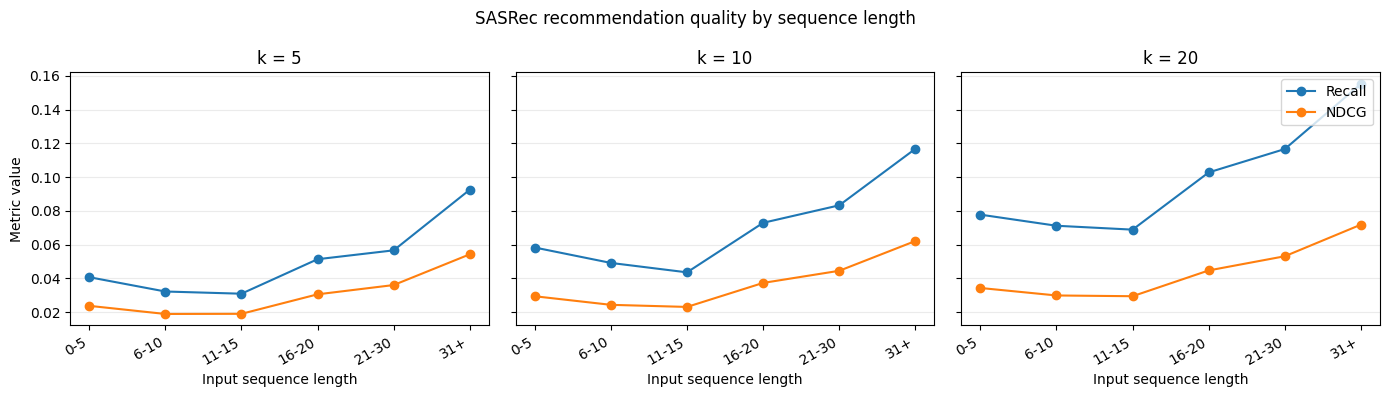

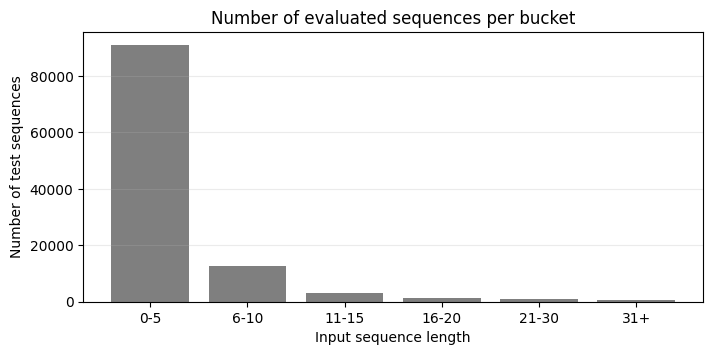

In [11]:
metric_cols = [col for col in length_group_metrics.columns if "@" in col]
display(length_group_metrics.style.format({col: "{:.4f}" for col in metric_cols}))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, k in zip(axes, [5, 10, 20]):
    x = np.arange(len(length_group_metrics))
    ax.plot(x, length_group_metrics[f"Recall@{k}"], marker="o", label="Recall")
    ax.plot(x, length_group_metrics[f"NDCG@{k}"], marker="o", label="NDCG")
    ax.set_title(f"k = {k}")
    ax.set_xticks(x)
    ax.set_xticklabels(length_group_metrics["bucket"].astype(str), rotation=30, ha="right")
    ax.set_xlabel("Input sequence length")
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Metric value")
axes[-1].legend(loc="upper right")
fig.suptitle("SASRec recommendation quality by sequence length")
fig.tight_layout()
plt.show()

plt.figure(figsize=(8, 3.5))
plt.bar(length_group_metrics["bucket"].astype(str), length_group_metrics["sequences"], color="tab:gray")
plt.xlabel("Input sequence length")
plt.ylabel("Number of test sequences")
plt.title("Number of evaluated sequences per bucket")
plt.grid(axis="y", alpha=0.25)
plt.show()


# Task 2 [2 points]
1. Train and evaluate the LightGCN model. Use a proper data split. Calculate the metrics (at least
recall and nDCG) for k = 5, 10, 20 (note that you don’t need to calculate the recommendations
multiple times to do so).
2. Analyze the popularity of items:
- Calculate the popularity of each item. Make a bar plot with ordered popularities (from
largest to smallest).
- Analyze the popularity of the items you have recommended: how popular are the items
you recommend, and how often items of different popularity are recommended.
- By doing this analysis, you can observe the Matthew effect for Recommender Systems.
Explain it.

### LightGCN training and evaluation

For LightGCN I use the same filtered Amazon Beauty interactions, but with a general recommendation setup: BPR loss, uniform negative sampling during training, full-sort evaluation, and a temporal leave-one-out split per user. The split keeps each user's latest interaction for test and the previous one for validation, so validation/test items are later than the training interactions.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import torch

from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.utils import get_model, get_trainer, init_seed

# np.float_ = np.float64
# np.complex_ = np.complex128
# np.unicode_ = np.str_


True


In [2]:
task2_config_dict = {
    # Amazon Beauty sequential recommendation data
    "USER_ID_FIELD": "user_id",
    "ITEM_ID_FIELD": "item_id",
    "TIME_FIELD": "timestamp",
    "load_col": {"inter": ["user_id", "item_id", "timestamp"]},  # load user-item interactions with timestamp
    "ITEM_LIST_LENGTH_FIELD": "item_length",
    "LIST_SUFFIX": "_list",
    "MAX_ITEM_LIST_LENGTH": 35,  # maximum length of the item sequence for each user

    # filter out users with less than X interactions or more than X interactions
    "user_inter_num_interval": "[3,inf)",
    # filter out items with less than X interactions
    "item_inter_num_interval": "[3,inf)",

    # Sequential leave-one-out split: last item test, second last item validation
    "eval_args": {
        "group_by": "user", # group by user for splitting
        "order": "TO",  # time order
        "split": {"LS": "valid_and_test"}, # leave-one-out split
        "mode": "full", # use all the data for evaluation
    },

    # Model and optimization
    # "loss_type": "CE",  # Cross-Entropy loss
    # "train_neg_sample_args": None,
    "loss_type": "BPR",     # Bayesian Personalized Ranking loss
    "train_neg_sample_args": {"distribution": "uniform", "sample_num": 1},
    "epochs": 10,
    "stopping_step": 1,
    "train_batch_size": 1024 * 8,
    "eval_batch_size": 1024 * 8,
    "learning_rate": 1e-3,
    "hidden_size": 32,
    "inner_size": 64,
    "n_layers": 2,
    "n_heads": 2,
    "hidden_dropout_prob": 0.2,
    "attn_dropout_prob": 0.2,

    # Metrics
    "metrics": ["Recall", "NDCG"],
    "topk": [5, 10, 20],
    "valid_metric": "NDCG@10",
    "metric_decimal_place": 4,
    "seed": 42,
    "reproducibility": False,
}

config = Config(model="SASRec", dataset="amazon-beauty", config_dict=task2_config_dict)
init_seed(config["seed"], config["reproducibility"])

dataset = create_dataset(config)
train_data, valid_data, test_data = data_preparation(config, dataset)

model = get_model(config["model"])(config, train_data.dataset).to(config["device"])
trainer = get_trainer(config["MODEL_TYPE"], config["model"])(config, model)

best_valid_score, best_valid_result = trainer.fit(
    train_data,
    valid_data,
    saved=True,
    show_progress=True,
)
test_result = trainer.evaluate(
    test_data,
    load_best_model=True,
    show_progress=True,
)

print("Best validation score:", best_valid_score)
print("Best validation metrics:", best_valid_result)
print("Test metrics:", test_result)


D:\SharedData\Documents\GitHub\UWr\Sem8\ADM\List6\.venv\Lib\site-packages\recbole\data\dataset\dataset.py:648: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  feat[field].fillna(value=0, inplace=True)
D:\SharedData\Documents\GitHub\UWr\Sem8\ADM\List6\.venv\Lib\site-packages\recbole\data\dataset\dataset.py:650: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

Best validation score: 0.0088
Best validation metrics: OrderedDict({'recall@5': 0.0107, 'recall@10': 0.0179, 'recall@20': 0.0288, 'ndcg@5': 0.0065, 'ndcg@10': 0.0088, 'ndcg@20': 0.0116})
Test metrics: OrderedDict({'recall@5': 0.0089, 'recall@10': 0.0144, 'recall@20': 0.0221, 'ndcg@5': 0.0055, 'ndcg@10': 0.0073, 'ndcg@20': 0.0092})


In [5]:
def full_sort_topk(model, eval_data, config, k=20):
    """Return one full-sort top-k recommendation table for all evaluated users."""
    model.eval()
    device = config["device"]
    user_field = config["USER_ID_FIELD"]
    item_field = config["ITEM_ID_FIELD"]
    n_items = eval_data.dataset.item_num
    rows = []

    with torch.no_grad():
        for batched_data in eval_data:
            interaction, history_index, positive_u, positive_i = batched_data
            interaction = interaction.to(device)

            scores = model.full_sort_predict(interaction).view(-1, n_items)
            scores[:, 0] = -torch.inf  # RecBole id 0 is padding.
            if history_index is not None:
                history_index = tuple(
                    x.to(device) if torch.is_tensor(x) else x for x in history_index
                )
                scores[history_index] = -torch.inf

            top_items = torch.topk(scores, k=k, dim=1).indices.cpu().numpy()
            users = interaction[user_field].detach().cpu().numpy()
            positive_by_row = torch.full((scores.size(0),), -1, device=device, dtype=torch.long)
            positive_by_row[positive_u.to(device)] = positive_i.to(device)
            positives = positive_by_row.cpu().numpy()

            for row_idx, user_id in enumerate(users):
                for rank, item_id in enumerate(top_items[row_idx], start=1):
                    rows.append({
                        "user_id": int(user_id),
                        "item_id": int(item_id),
                        "rank": rank,
                        "positive_item_id": int(positives[row_idx]),
                    })

    recs = pd.DataFrame(rows)
    recs["user_token"] = recs["user_id"].map(lambda x: eval_data.dataset.id2token(user_field, x))
    recs["item_token"] = recs["item_id"].map(lambda x: eval_data.dataset.id2token(item_field, x))
    recs["positive_item_token"] = recs["positive_item_id"].map(
        lambda x: eval_data.dataset.id2token(item_field, x) if x >= 0 else None
    )
    return recs


recommendations = full_sort_topk(model, test_data, config, k=20)
recommendations.head()

,user_id,item_id,rank,positive_item_id,user_token,item_token,positive_item_token
0,595,40556,1,44493,A281NPSIMI1C2R,B00AHF1GTM,B00FRDPR4O
1,595,32714,2,44493,A281NPSIMI1C2R,B00639DLV2,B00FRDPR4O
2,595,38355,3,44493,A281NPSIMI1C2R,B008U2Y9BQ,B00FRDPR4O
3,595,34954,4,44493,A281NPSIMI1C2R,B007BLN17K,B00FRDPR4O
4,595,40381,5,44493,A281NPSIMI1C2R,B00AE0790U,B00FRDPR4O


### Item popularity

Popularity is counted on the training interactions only. This avoids using validation/test interactions to describe what the model could already have learned during fitting.

In [7]:
# tensor -> numpy for pandas
def _as_numpy(x):
    return x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)


In [8]:
item_field = config["ITEM_ID_FIELD"]
train_item_ids = _as_numpy(train_data.dataset.inter_feat[item_field]).astype(int)

item_popularity = (
    pd.Series(train_item_ids, name="item_id")
    .value_counts()
    .rename_axis("item_id")
    .reset_index(name="train_popularity")
    .sort_values("train_popularity", ascending=False)
    .reset_index(drop=True)
)
item_popularity["popularity_rank"] = np.arange(1, len(item_popularity) + 1)
item_popularity["item_token"] = item_popularity["item_id"].map(
    lambda x: train_data.dataset.id2token(item_field, int(x))
)

# Include rank bins from very popular head items to the long tail.
item_popularity["popularity_bucket"] = pd.qcut(
    item_popularity["popularity_rank"],
    q=[0, 0.01, 0.05, 0.20, 1.0],
    labels=["top 1%", "1-5%", "5-20%", "bottom 80%"],
)

item_popularity.head(10)

,item_id,train_popularity,popularity_rank,item_token,popularity_bucket
0,9554,493,1,B000ZMBSPE,top 1%
1,27913,463,2,B004OHQR1Q,top 1%
2,25058,451,3,B0043OYFKU,top 1%
3,33047,414,4,B0069FDR96,top 1%
4,10828,365,5,B00150LT40,top 1%
5,15427,356,6,B001MA0QY2,top 1%
6,33535,353,7,B006L1DNWY,top 1%
7,23896,353,8,B003V265QW,top 1%
8,34954,318,9,B007BLN17K,top 1%
9,695,293,10,B000142FVW,top 1%


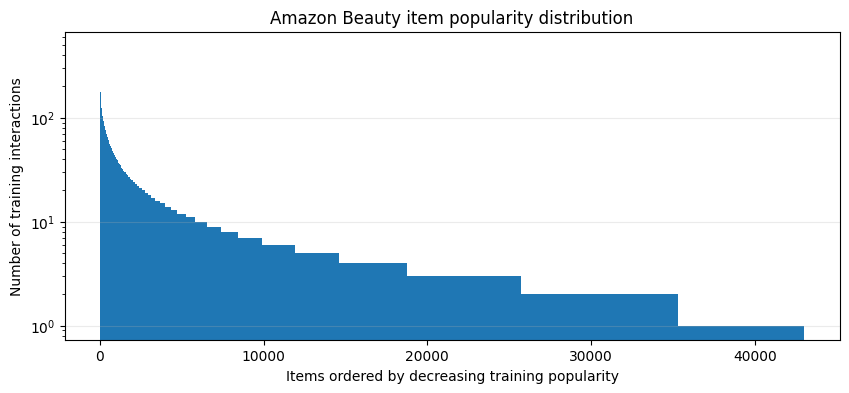

In [9]:
plt.figure(figsize=(10, 4))
plt.bar(item_popularity["popularity_rank"], item_popularity["train_popularity"], width=1.0)
plt.xlabel("Items ordered by decreasing training popularity")
plt.ylabel("Number of training interactions")
plt.title("Amazon Beauty item popularity distribution")
plt.yscale("log")
plt.grid(axis="y", alpha=0.25)
plt.show()

### Popularity of recommended items

In [10]:
recommended_popularity = recommendations.merge(
    item_popularity[["item_id", "train_popularity", "popularity_rank", "popularity_bucket"]],
    on="item_id",
    how="left",
)
recommended_popularity["train_popularity"] = recommended_popularity["train_popularity"].fillna(0).astype(int)

popularity_summary_by_k = []
for k in [5, 10, 20]:
    recs_at_k = recommended_popularity[recommended_popularity["rank"] <= k]
    popularity_summary_by_k.append({
        "k": k,
        "recommendations": len(recs_at_k),
        "unique_items": recs_at_k["item_id"].nunique(),
        "mean_train_popularity": recs_at_k["train_popularity"].mean(),
        "median_train_popularity": recs_at_k["train_popularity"].median(),
        "mean_popularity_rank": recs_at_k["popularity_rank"].mean(),
        "share_from_top_1pct": (recs_at_k["popularity_bucket"] == "top 1%").mean(),
        "share_from_bottom_80pct": (recs_at_k["popularity_bucket"] == "bottom 80%").mean(),
    })

popularity_summary_by_k = pd.DataFrame(popularity_summary_by_k)
display(popularity_summary_by_k.style.format({
    "mean_train_popularity": "{:.2f}",
    "median_train_popularity": "{:.2f}",
    "mean_popularity_rank": "{:.1f}",
    "share_from_top_1pct": "{:.2%}",
    "share_from_bottom_80pct": "{:.2%}",
}))

bucket_distribution = (
    recommended_popularity[recommended_popularity["rank"] <= 20]
    .groupby("popularity_bucket", observed=False)
    .agg(
        recommendations=("item_id", "size"),
        unique_items=("item_id", "nunique"),
        mean_rank=("rank", "mean"),
    )
    .reset_index()
)
bucket_distribution["recommendation_share"] = (
    bucket_distribution["recommendations"] / bucket_distribution["recommendations"].sum()
)

display(bucket_distribution.style.format({
    "mean_rank": "{:.2f}",
    "recommendation_share": "{:.2%}",
}))

,k,recommendations,unique_items,mean_train_popularity,median_train_popularity,mean_popularity_rank,share_from_top_1pct,share_from_bottom_80pct
0,5,548620,4777,284.21,270.00,352.2,95.59%,1.07%
1,10,1097240,7448,252.69,240.00,366.0,94.61%,1.06%
2,20,2194480,11238,221.13,192.00,396.0,92.88%,1.07%


,popularity_bucket,recommendations,unique_items,mean_rank,recommendation_share
0,top 1%,2038152,419,10.37,92.96%
1,1-5%,109524,1181,12.66,5.00%
2,5-20%,21392,1991,11.35,0.98%
3,bottom 80%,23446,6983,10.52,1.07%


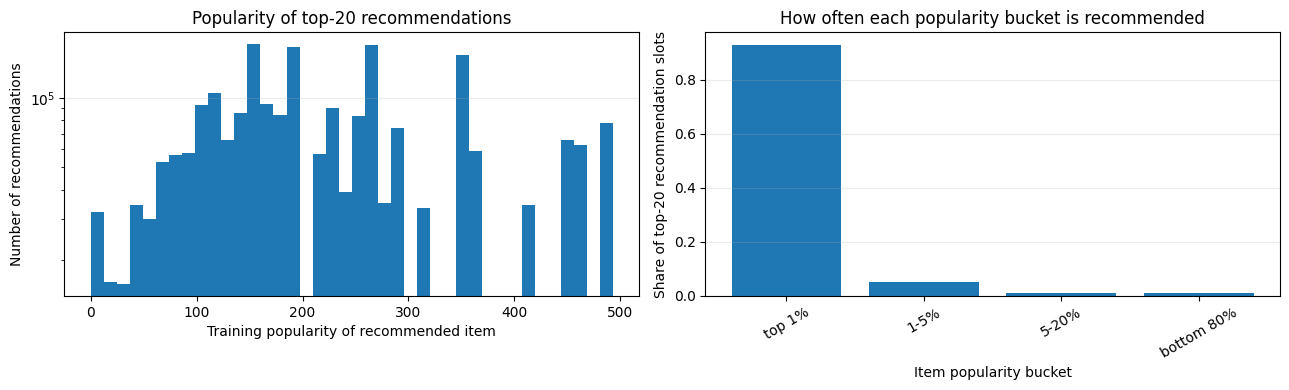

,item_id,train_popularity,popularity_rank,popularity_bucket,times_recommended
3406,15427,356,6.0,top 1%,79744
2160,9554,493,1.0,top 1%,77446
5567,25058,451,3.0,top 1%,65845
6159,27913,463,2.0,top 1%,62719
2435,10828,365,5.0,top 1%,58831
205,878,222,23.0,top 1%,54636
6278,28488,190,32.0,top 1%,54394
169,695,293,10.0,top 1%,46784
7430,33535,353,7.0,top 1%,43463
1905,8397,152,63.0,top 1%,42945


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(recommended_popularity.loc[recommended_popularity["rank"] <= 20, "train_popularity"], bins=40)
axes[0].set_xlabel("Training popularity of recommended item")
axes[0].set_ylabel("Number of recommendations")
axes[0].set_title("Popularity of top-20 recommendations")
axes[0].set_yscale("log")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    bucket_distribution["popularity_bucket"].astype(str),
    bucket_distribution["recommendation_share"],
)
axes[1].set_xlabel("Item popularity bucket")
axes[1].set_ylabel("Share of top-20 recommendation slots")
axes[1].set_title("How often each popularity bucket is recommended")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

recommended_item_frequency = (
    recommended_popularity[recommended_popularity["rank"] <= 20]
    .groupby(["item_id", "train_popularity", "popularity_rank", "popularity_bucket"], observed=True)
    .size()
    .reset_index(name="times_recommended")
    .sort_values("times_recommended", ascending=False)
)
recommended_item_frequency.head(10)

### Matthew effect

The Matthew effect means that items that are already popular receive even more exposure from the recommender. In LightGCN, popular items are connected to many users in the interaction graph, so their embeddings are updated from more signals and they tend to be close to many user embeddings. As a result, the top recommendation slots are usually occupied disproportionately by head items, while long-tail items receive fewer recommendation opportunities. The popularity tables and bucket plot above show this by comparing the training popularity distribution with the popularity distribution inside the top-20 recommendation lists.

# Task 3 [3 points]
Use the LightGCN backbone and the Yelp2018 dataset. Compare several augmentation strategies
for contrastive learning in recommender systems.
1. Train models with the following augmentation strategies:
- Randomly drop 20% of edges in the graph (drop interactions).
- Randomly drop 20% of vertices in the graph (drop users/items).
- Normalize the embeddings to a unit sphere and add noise to the latent item representa-
tions.
Apply the augmentations separately in each mini-batch and in each epoch to ensure robustness.
2. Use the loss function: L = BPR+λ1(InfoNCE for users + InfoNCE for items)+λ2 regularization.
For drops, you can use the L2 regularization term; for noise, you can use the RBF function to
ensure uniformity.
3. For evaluation, repeat the analyzes from Task 1 and Task 2.
In this task, you are comparing SGL (https://dl.acm.org/doi/10.1145/3404835.3462862) and
SimGCL (https://dl.acm.org/doi/10.1145/3477495.3531937). You can find all the implementation
details in the literature. You can also use the implementations from the package
https://github.com/RUCAIBox/RecBole-GNN/tree/main